# VNNLib Benchmark Visualization
Demonstrate ACT's VNNLib loader with ACAS Xu network visualization

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

## CIFAR-100 VNNLib Benchmark Test

Test fully-trained CIFAR-100 models from VNNLib benchmarks.
These models are trained on CIFAR-100 (not ImageNet pre-trained), so they should provide meaningful predictions.

TESTING CIFAR-100 VNNLIB BENCHMARK INSTANCES
✓ Loaded 20 VNNLib instances



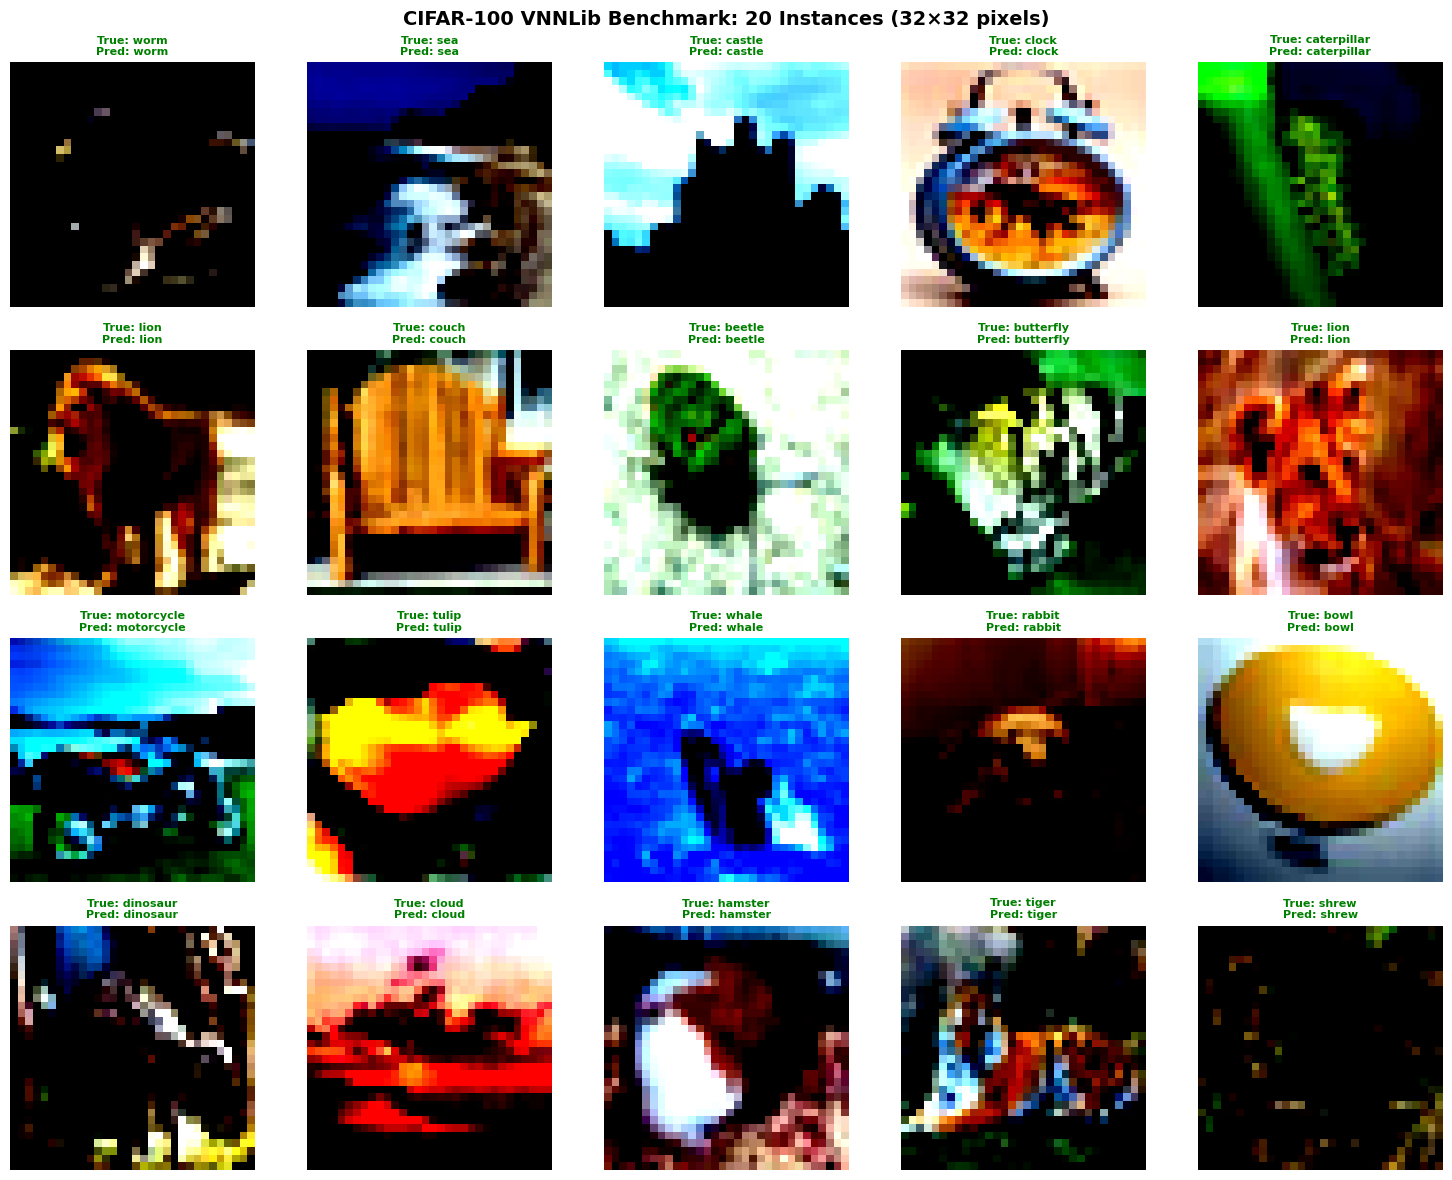

RESULTS: 20/20 correct (100.0% accuracy)

ℹ️  CIFAR-100 has 100 classes (random guess: 1% accuracy)
   Expected accuracy for trained model: 60-80%
   Actual accuracy: 100.0%

DETAILED RESULTS:
   1. ✓ True: worm            | Pred: worm           
   2. ✓ True: sea             | Pred: sea            
   3. ✓ True: castle          | Pred: castle         
   4. ✓ True: clock           | Pred: clock          
   5. ✓ True: caterpillar     | Pred: caterpillar    
   6. ✓ True: lion            | Pred: lion           
   7. ✓ True: couch           | Pred: couch          
   8. ✓ True: beetle          | Pred: beetle         
   9. ✓ True: butterfly       | Pred: butterfly      
  10. ✓ True: lion            | Pred: lion           
  11. ✓ True: motorcycle      | Pred: motorcycle     
  12. ✓ True: tulip           | Pred: tulip          
  13. ✓ True: whale           | Pred: whale          
  14. ✓ True: rabbit          | Pred: rabbit         
  15. ✓ True: bowl            | Pred: bowl         

In [2]:
# Test CIFAR-100 VNNLib Benchmark Instances
import sys
import os
act_root = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if act_root not in sys.path:
    sys.path.insert(0, act_root)

import torch
import matplotlib.pyplot as plt
import numpy as np
from act.front_end.vnnlib_loader.create_specs import VNNLibSpecCreator

# CIFAR-100 class names (100 fine-grained classes)
CIFAR100_CLASSES = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

print("="*100)
print("TESTING CIFAR-100 VNNLIB BENCHMARK INSTANCES")
print("="*100)

try:
    # Load 20 VNNLib instances (now returns LabeledInputTensors)
    creator = VNNLibSpecCreator(config_name="vnnlib_default")
    spec_results = creator.create_specs_for_data_model_pairs(
        categories=["cifar100_2024"],
        max_instances=20,
        validate_shapes=True
    )
    
    if not spec_results:
        raise RuntimeError("No CIFAR-100 instances found")
    
    print(f"✓ Loaded {len(spec_results)} VNNLib instances\n")
    
    # Collect data from all instances
    images = []
    true_labels = []
    pred_labels = []
    
    # Get first model for inference
    _, _, first_model, _, _ = spec_results[0]
    first_model.eval()
    
    for idx, (category, instance_id, model, labeled_tensors, spec_pairs) in enumerate(spec_results):
        # Unpack LabeledInputTensor (new clean approach - no manual label extraction!)
        labeled_tensor = labeled_tensors[0]
        input_tensor, true_label = labeled_tensor  # Tuple unpacking
                
        # Run inference (use first model for all - they're the same architecture)
        with torch.no_grad():
            output = first_model(input_tensor)
            pred_label = output.argmax(dim=1).item()
        
        # Reshape input_tensor for visualization
        if input_tensor.dim() == 1:
            # Flat tensor: 3072 → 3×32×32 → 32×32×3
            img = input_tensor.reshape(3, 32, 32).permute(1, 2, 0)
        elif input_tensor.dim() == 3:
            # Already 3×32×32 → 32×32×3
            img = input_tensor.permute(1, 2, 0)
        elif input_tensor.dim() == 4:
            # Batch dimension: squeeze and permute
            img = input_tensor.squeeze(0).permute(1, 2, 0)
        else:
            img = input_tensor
        
        images.append(img)
        true_labels.append(true_label if true_label is not None else -1)
        pred_labels.append(pred_label)
    
    # Visualize results
    correct = sum(1 for t, p in zip(true_labels, pred_labels) if t == p and t != -1)
    valid_count = sum(1 for t in true_labels if t != -1)
    
    fig, axes = plt.subplots(4, 5, figsize=(15, 12), dpi=100)
    fig.suptitle('CIFAR-100 VNNLib Benchmark: 20 Instances (32×32 pixels)', 
                 fontsize=14, fontweight='bold')
    
    for idx, ax in enumerate(axes.flat):
        if idx < len(images):
            img = images[idx]
            true_label = true_labels[idx]
            pred_label = pred_labels[idx]
            
            # Display image (denormalize if needed for visualization)
            img_display = img.cpu().numpy()
            # Clip to [0, 1] range
            img_display = np.clip(img_display, 0, 1)
            ax.imshow(img_display, interpolation='nearest')
            
            # Get class names
            true_class = CIFAR100_CLASSES[true_label] if true_label != -1 else '?'
            pred_class = CIFAR100_CLASSES[pred_label]
            
            # Color code by correctness
            if true_label == -1:
                color = 'orange'
                title = f'True: ?\nPred: {pred_class}'
            else:
                is_correct = (pred_label == true_label)
                color = 'green' if is_correct else 'red'
                title = f'True: {true_class}\nPred: {pred_class}'
            
            ax.set_title(title, color=color, fontweight='bold', fontsize=8)
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Results
    if valid_count > 0:
        accuracy = (correct / valid_count) * 100
        print(f"{'='*100}")
        print(f"RESULTS: {correct}/{valid_count} correct ({accuracy:.1f}% accuracy)")
        print(f"{'='*100}")
        print(f"\nℹ️  CIFAR-100 has 100 classes (random guess: 1% accuracy)")
        print(f"   Expected accuracy for trained model: 60-80%")
        print(f"   Actual accuracy: {accuracy:.1f}%")
        
        # Print detailed results with class names
        print(f"\nDETAILED RESULTS:")
        for i, (true_label, pred_label) in enumerate(zip(true_labels, pred_labels)):
            if true_label != -1:
                true_class = CIFAR100_CLASSES[true_label]
                pred_class = CIFAR100_CLASSES[pred_label]
                status = "✓" if true_label == pred_label else "✗"
                print(f"  {i+1:2d}. {status} True: {true_class:15s} | Pred: {pred_class:15s}")
        
        if accuracy > 30:
            print(f"\n✓ VNNLib benchmark model is working correctly!")
        else:
            print(f"\n⚠️  Accuracy lower than expected")
    else:
        print(f"\n⚠️  Could not extract ground truth labels from VNNLIB files")
        print(f"   Showing predictions only")
    
    print(f"\n💡 Using LabeledInputTensor: input_tensor paired with ground_truth label")
    print(f"   Labels extracted automatically from VNNLIB comments!")
    print(f"   Clean, maintainable code with no manual parsing!")

except Exception as e:
    import traceback
    print(f"\n⚠️ Error: {e}")
    traceback.print_exc()
    print(f"\n💡 Download CIFAR-100 benchmarks:")
    print(f"   python -m act.front_end.vnnlib_loader.cli --download cifar100_2024")


## White-Box Input Perturbation Fuzzing

Test model robustness using white-box attacks with epsilon values from VNNLib specifications.
Compares random noise vs. gradient-based adversarial perturbations (FGSM/PGD).

WHITE-BOX FUZZING: Robustness Testing with Gradient-Based Perturbations
✓ Loaded 12 VNNLib instances

✓ Using epsilon from VNNLib spec: 0.030590



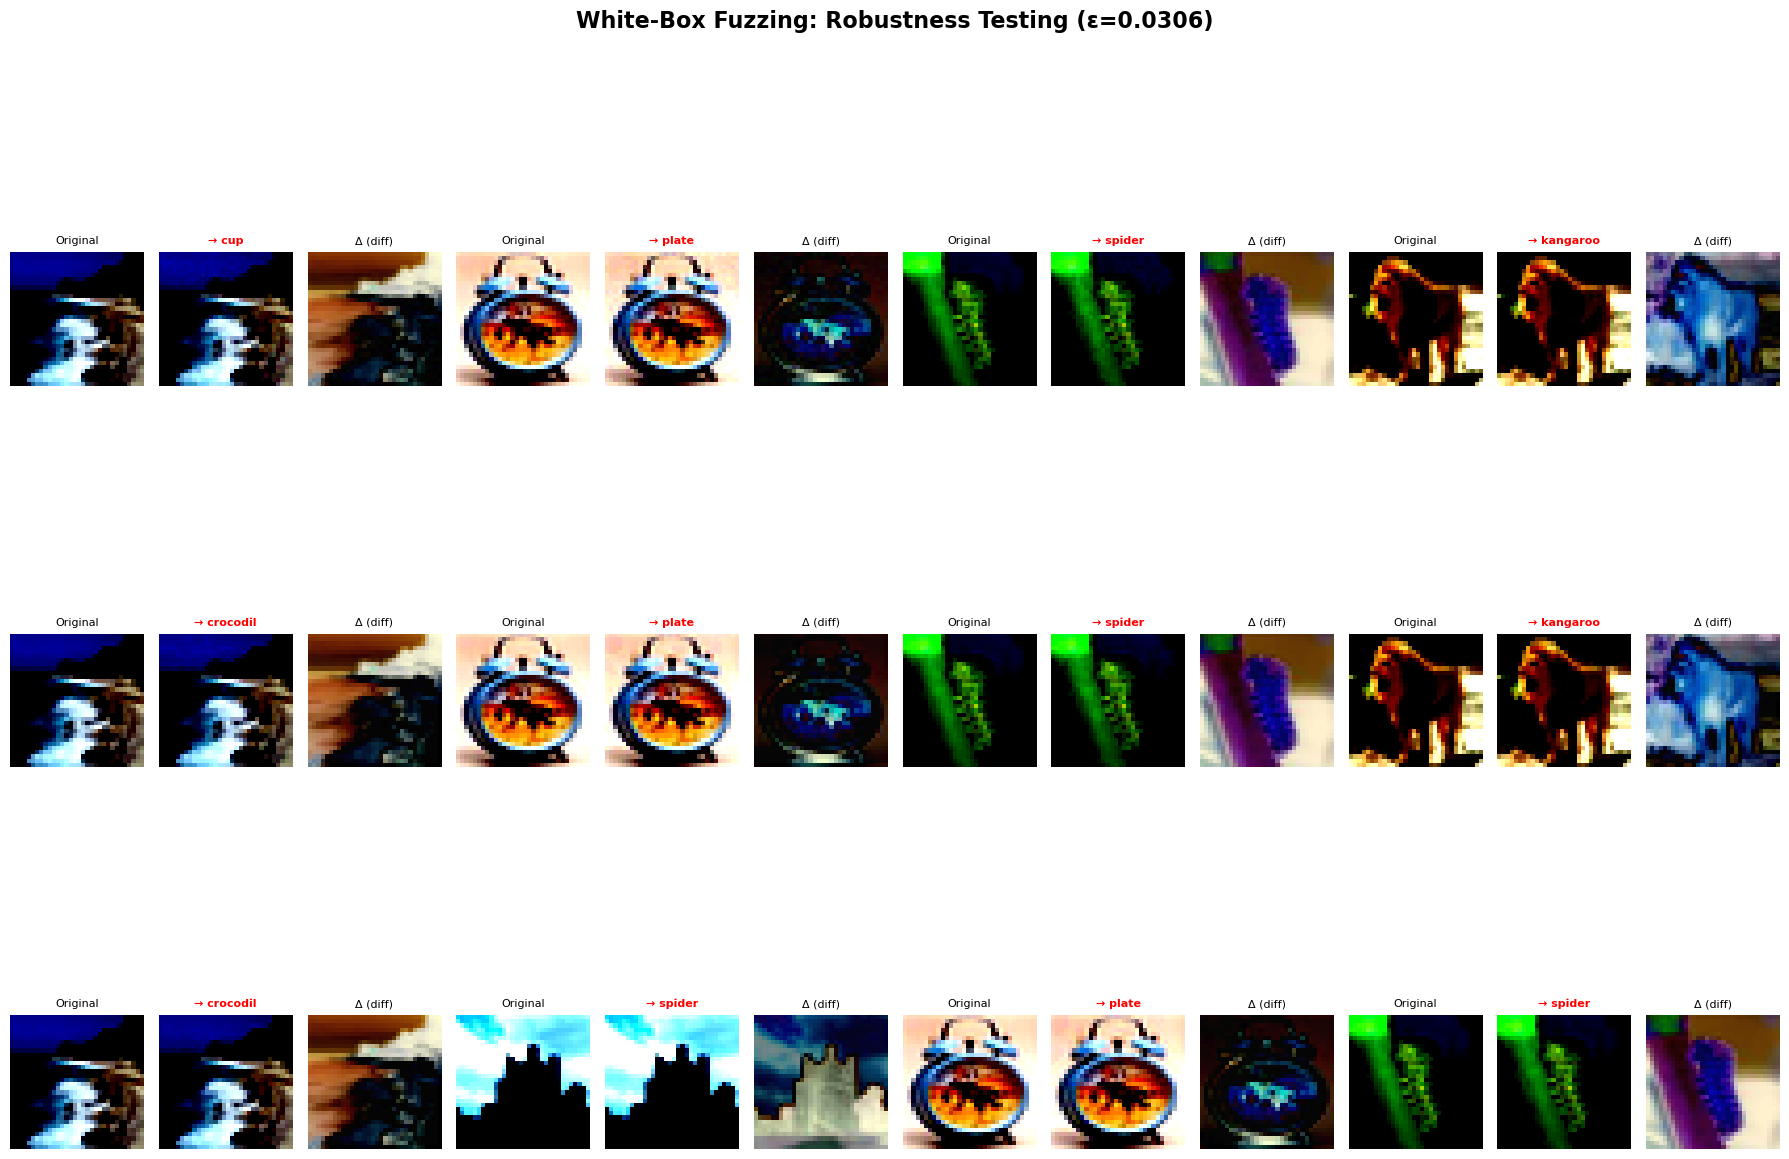


ROBUSTNESS ANALYSIS RESULTS
Epsilon: 0.030590 (from VNNLib specification)
Tested: 12 instances

Random   Attack:  9/12 successful ( 75.0% flip rate)
FGSM     Attack: 10/12 successful ( 83.3% flip rate)
PGD      Attack: 11/12 successful ( 91.7% flip rate)

💡 Key Insights:
   • Random noise: Weakest attack (black-box baseline)
   • FGSM: Fast white-box attack using gradients
   • PGD: Strongest iterative white-box attack
   • Higher flip rate = Less robust model

✓ White-box fuzzing reveals vulnerabilities even within ε=0.0306 bounds!
   This demonstrates why formal verification is crucial for safety-critical systems.


In [3]:
# White-Box Fuzzing: Test Robustness with Gradient-Based Attacks
import sys
import os
act_root = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if act_root not in sys.path:
    sys.path.insert(0, act_root)

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from act.front_end.vnnlib_loader.create_specs import VNNLibSpecCreator

print("="*100)
print("WHITE-BOX FUZZING: Robustness Testing with Gradient-Based Perturbations")
print("="*100)

def fgsm_attack(model, input_tensor, true_label, epsilon):
    """Fast Gradient Sign Method - single-step white-box attack"""
    input_tensor.requires_grad = True
    output = model(input_tensor)
    loss = F.cross_entropy(output, torch.tensor([true_label]))
    model.zero_grad()
    loss.backward()
    
    # Generate perturbation
    perturbation = epsilon * input_tensor.grad.sign()
    perturbed = input_tensor + perturbation
    
    # Clip to valid range [0, 1]
    perturbed = torch.clamp(perturbed, 0, 1)
    return perturbed.detach()

def pgd_attack(model, input_tensor, true_label, epsilon, alpha=0.01, num_steps=10):
    """Projected Gradient Descent - iterative white-box attack (stronger)"""
    perturbed = input_tensor.clone().detach()
    
    for _ in range(num_steps):
        perturbed.requires_grad = True
        output = model(perturbed)
        loss = F.cross_entropy(output, torch.tensor([true_label]))
        model.zero_grad()
        loss.backward()
        
        # Update with gradient
        perturbation = alpha * perturbed.grad.sign()
        perturbed = perturbed.detach() + perturbation
        
        # Project back to epsilon ball around original
        delta = torch.clamp(perturbed - input_tensor, -epsilon, epsilon)
        perturbed = torch.clamp(input_tensor + delta, 0, 1)
    
    return perturbed

def random_noise_attack(input_tensor, epsilon):
    """Random noise perturbation (baseline)"""
    noise = torch.randn_like(input_tensor) * epsilon
    perturbed = input_tensor + noise
    return torch.clamp(perturbed, 0, 1)

try:
    # Load VNNLib instances
    creator = VNNLibSpecCreator(config_name="vnnlib_default")
    spec_results = creator.create_specs_for_data_model_pairs(
        categories=["cifar100_2024"],
        max_instances=12,  # Test on 12 instances for visualization
        validate_shapes=True
    )
    
    if not spec_results:
        raise RuntimeError("No CIFAR-100 instances found")
    
    print(f"✓ Loaded {len(spec_results)} VNNLib instances\n")
    
    # Extract epsilon from first input spec
    _, _, _, _, spec_pairs = spec_results[0]
    input_spec, _ = spec_pairs[0]
    epsilon = float((input_spec.ub - input_spec.lb).max())  # Get max epsilon from spec
    print(f"✓ Using epsilon from VNNLib spec: {epsilon:.6f}\n")
    
    # Get model
    _, _, model, _, _ = spec_results[0]
    model.eval()
    
    # Test all three attack methods
    attack_results = {
        'Random': {'success': 0, 'examples': []},
        'FGSM': {'success': 0, 'examples': []},
        'PGD': {'success': 0, 'examples': []}
    }
    
    for idx, (category, instance_id, _, labeled_tensors, spec_pairs) in enumerate(spec_results):
        labeled_tensor = labeled_tensors[0]
        input_tensor, true_label = labeled_tensor
        
        # Get original prediction
        with torch.no_grad():
            orig_output = model(input_tensor)
            orig_pred = orig_output.argmax(dim=1).item()
        
        # Only test if original prediction is correct
        if orig_pred != true_label:
            continue
        
        # Test each attack method
        attacks = {
            'Random': random_noise_attack(input_tensor, epsilon),
            'FGSM': fgsm_attack(model, input_tensor.clone(), true_label, epsilon),
            'PGD': pgd_attack(model, input_tensor.clone(), true_label, epsilon)
        }
        
        for attack_name, perturbed in attacks.items():
            with torch.no_grad():
                pert_output = model(perturbed)
                pert_pred = pert_output.argmax(dim=1).item()
            
            # Check if attack succeeded (prediction changed)
            if pert_pred != orig_pred:
                attack_results[attack_name]['success'] += 1
                if len(attack_results[attack_name]['examples']) < 4:  # Keep 4 examples
                    # Prepare images for visualization
                    orig_img = input_tensor.reshape(3, 32, 32).permute(1, 2, 0).cpu().numpy()
                    pert_img = perturbed.reshape(3, 32, 32).permute(1, 2, 0).cpu().numpy()
                    diff_img = np.abs(pert_img - orig_img)
                    
                    attack_results[attack_name]['examples'].append({
                        'original': np.clip(orig_img, 0, 1),
                        'perturbed': np.clip(pert_img, 0, 1),
                        'difference': diff_img / diff_img.max() if diff_img.max() > 0 else diff_img,
                        'orig_pred': orig_pred,
                        'pert_pred': pert_pred,
                        'true_label': true_label
                    })
    
    # Visualization
    fig = plt.figure(figsize=(18, 14))
    fig.suptitle(f'White-Box Fuzzing: Robustness Testing (ε={epsilon:.4f})', 
                 fontsize=16, fontweight='bold')
    
    attack_names = ['Random', 'FGSM', 'PGD']
    for attack_idx, attack_name in enumerate(attack_names):
        examples = attack_results[attack_name]['examples']
        success_rate = attack_results[attack_name]['success']
        
        for ex_idx, example in enumerate(examples[:4]):
            # Original image
            ax1 = plt.subplot(3, 12, attack_idx * 12 + ex_idx * 3 + 1)
            ax1.imshow(example['original'], interpolation='nearest')
            if ex_idx == 0:
                ax1.set_ylabel(f'{attack_name}\n{success_rate}/{len(spec_results)} flipped', 
                              fontsize=10, fontweight='bold')
            ax1.set_title('Original', fontsize=8)
            ax1.axis('off')
            
            # Perturbed image
            ax2 = plt.subplot(3, 12, attack_idx * 12 + ex_idx * 3 + 2)
            ax2.imshow(example['perturbed'], interpolation='nearest')
            pred_class = CIFAR100_CLASSES[example['pert_pred']]
            ax2.set_title(f'→ {pred_class[:8]}', fontsize=8, color='red', fontweight='bold')
            ax2.axis('off')
            
            # Difference (amplified)
            ax3 = plt.subplot(3, 12, attack_idx * 12 + ex_idx * 3 + 3)
            ax3.imshow(example['difference'], cmap='hot', interpolation='nearest')
            ax3.set_title('Δ (diff)', fontsize=8)
            ax3.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print(f"\n{'='*100}")
    print(f"ROBUSTNESS ANALYSIS RESULTS")
    print(f"{'='*100}")
    print(f"Epsilon: {epsilon:.6f} (from VNNLib specification)")
    print(f"Tested: {len(spec_results)} instances\n")
    
    for attack_name in attack_names:
        success = attack_results[attack_name]['success']
        success_rate = (success / len(spec_results)) * 100
        print(f"{attack_name:8s} Attack: {success:2d}/{len(spec_results)} successful ({success_rate:5.1f}% flip rate)")
    
    print(f"\n💡 Key Insights:")
    print(f"   • Random noise: Weakest attack (black-box baseline)")
    print(f"   • FGSM: Fast white-box attack using gradients")
    print(f"   • PGD: Strongest iterative white-box attack")
    print(f"   • Higher flip rate = Less robust model")
    print(f"\n✓ White-box fuzzing reveals vulnerabilities even within ε={epsilon:.4f} bounds!")
    print(f"   This demonstrates why formal verification is crucial for safety-critical systems.")

except Exception as e:
    import traceback
    print(f"\n⚠️ Error: {e}")
    traceback.print_exc()

## VNNLib ACAS Xu Perturbation Visualization

This section demonstrates:
- Loading ACAS Xu networks from VNNLib benchmarks
- Parsing VNNLIB specifications for input bounds
- Visualizing input specifications as bar charts
- Testing network behavior on sample points
- Interpreting ACAS Xu collision avoidance outputs

Loading ACAS Xu using VNNLibSpecCreator...

✓ Loaded: acasxu_2023/ACASXU_run2a_1_2_batch_2000_prop_1
✓ Model: GraphModule
✓ Input tensor shape: torch.Size([1, 1, 1, 5])
✓ Ground truth label: N/A
✓ Input spec: BOX (lb=torch.Size([1, 1, 1, 5]), ub=torch.Size([1, 1, 1, 5]))
✓ Output spec: UNSAFE_LINEAR



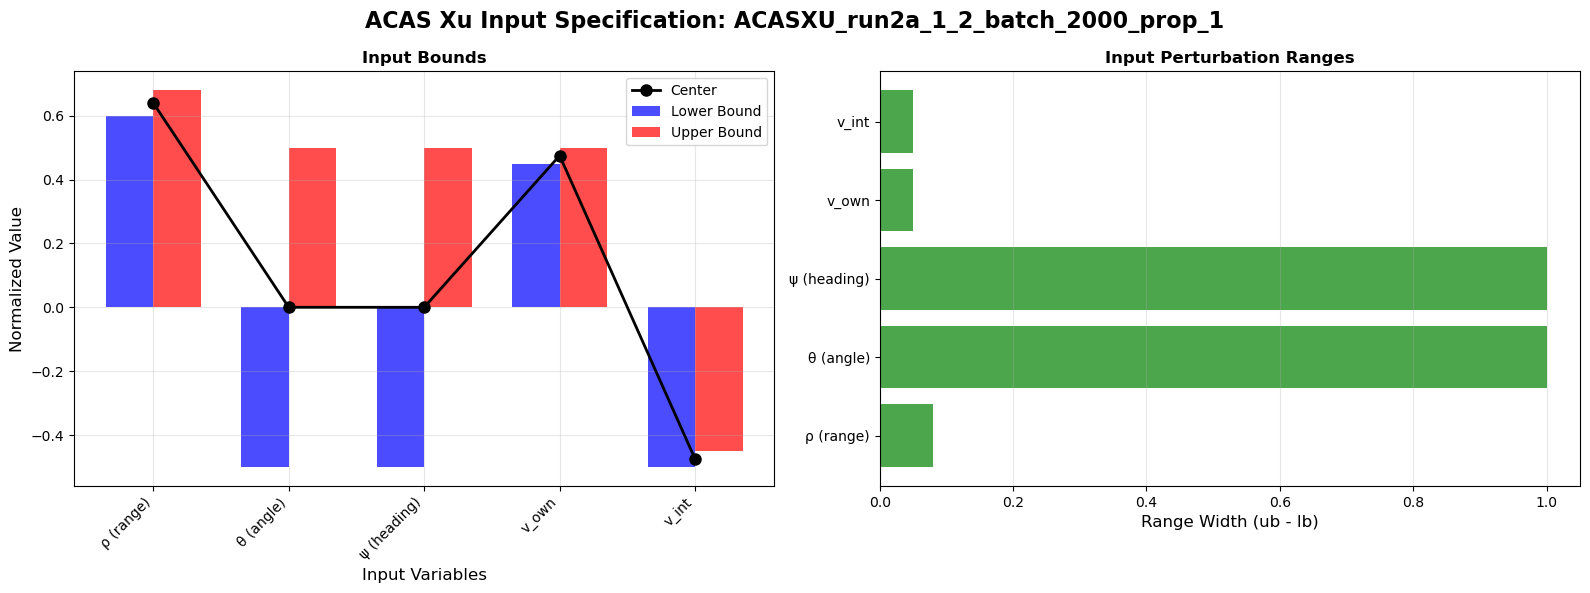

Testing Network on Sample Points

Lower Bound:
  Input: [ 0.6  -0.5  -0.5   0.45 -0.5 ]
  Output: [-0.0202845 -0.0193085 -0.019157  -0.0189128 -0.0189197]
  Recommended Action: Strong Left

Center:
  Input: [ 0.63992888  0.          0.          0.475      -0.475     ]
  Output: [-0.0203966  -0.01847512 -0.01822629 -0.01796024 -0.01798192]
  Recommended Action: Strong Left

Upper Bound:
  Input: [ 0.6798578  0.5        0.5        0.5       -0.45     ]
  Output: [-0.0202845 -0.0193085 -0.019157  -0.0189128 -0.0189197]
  Recommended Action: Strong Left

✓ Tested ACAS Xu network on 3 sample points


In [7]:
# ACT VNNLib: Visualize ACAS Xu Specs using VNNLibSpecCreator
import sys
import os

# Setup ACT paths
act_root = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if act_root not in sys.path:
    sys.path.insert(0, act_root)

import torch
import matplotlib.pyplot as plt
import numpy as np
from act.front_end.vnnlib_loader.create_specs import VNNLibSpecCreator

print("Loading ACAS Xu using VNNLibSpecCreator...\n")
try:
    # Create spec creator and load ACAS Xu
    creator = VNNLibSpecCreator(config_name="vnnlib_default")
    spec_results = creator.create_specs_for_data_model_pairs(
        categories=["acasxu_2023"],
        max_instances=1,
        validate_shapes=True
    )
    
    if not spec_results:
        raise RuntimeError("No ACAS Xu instances found")
    
    # Unpack first result (now uses LabeledInputTensor)
    category, instance_id, model, labeled_tensors, spec_pairs = spec_results[0]
    labeled_tensor = labeled_tensors[0]
    input_tensor, label = labeled_tensor  # Tuple unpacking
    input_spec, output_spec = spec_pairs[0]
    
    print(f"✓ Loaded: {category}/{instance_id}")
    print(f"✓ Model: {type(model).__name__}")
    print(f"✓ Input tensor shape: {input_tensor.shape}")
    print(f"✓ Ground truth label: {label if label is not None else 'N/A'}")
    print(f"✓ Input spec: {input_spec.kind} (lb={input_spec.lb.shape}, ub={input_spec.ub.shape})")
    print(f"✓ Output spec: {output_spec.kind}\n")
    
    # Extract bounds from InputSpec
    input_names = ['ρ (range)', 'θ (angle)', 'ψ (heading)', 'v_own', 'v_int']
    lb = input_spec.lb.cpu().numpy().flatten()
    ub = input_spec.ub.cpu().numpy().flatten()
    center = input_tensor.cpu().numpy().flatten()
    
    # Visualize bounds
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'ACAS Xu Input Specification: {instance_id}', fontsize=16, fontweight='bold')
    
    x = np.arange(len(input_names))
    width = 0.35
    
    axes[0].bar(x - width/2, lb, width, label='Lower Bound', color='blue', alpha=0.7)
    axes[0].bar(x + width/2, ub, width, label='Upper Bound', color='red', alpha=0.7)
    axes[0].plot(x, center, 'ko-', label='Center', linewidth=2, markersize=8)
    axes[0].set_xlabel('Input Variables', fontsize=12)
    axes[0].set_ylabel('Normalized Value', fontsize=12)
    axes[0].set_title('Input Bounds', fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(input_names, rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    ranges = ub - lb
    axes[1].barh(input_names, ranges, color='green', alpha=0.7)
    axes[1].set_xlabel('Range Width (ub - lb)', fontsize=12)
    axes[1].set_title('Input Perturbation Ranges', fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    # Test inference with lower bound, center, upper bound
    print("="*70)
    print("Testing Network on Sample Points")
    print("="*70)
    
    test_points = {
        'Lower Bound': input_spec.lb,
        'Center': input_tensor,
        'Upper Bound': input_spec.ub
    }
    
    model.eval()
    action_names = ['Clear-of-Conflict', 'Weak Left', 'Weak Right', 
                   'Strong Left', 'Strong Right']
    
    with torch.no_grad():
        for name, point in test_points.items():
            output = model(point)
            action = output.argmax(dim=1).item()
            print(f"\n{name}:")
            print(f"  Input: {point.cpu().numpy().flatten()}")
            print(f"  Output: {output.cpu().numpy().flatten()}")
            print(f"  Recommended Action: {action_names[action]}")
    
    print("\n" + "="*70)
    print(f"✓ Tested ACAS Xu network on {len(test_points)} sample points")
    
except Exception as e:
    import traceback
    print(f"⚠ Could not load ACAS Xu: {e}")
    traceback.print_exc()
    print("\n💡 Download ACAS Xu benchmarks:")
    print("  python -m act.front_end.vnnlib_loader.cli --download acasxu_2023")
    print("\nFalling back to CIFAR10 visualization...")
    
    # Fallback: Show CIFAR10
    import torchvision
    import torchvision.transforms as transforms
    
    cifar_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True,
        transform=transforms.ToTensor()
    )
    
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                   'dog', 'frog', 'horse', 'ship', 'truck']
    
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle('CIFAR10 Dataset - First 10 Images (Fallback)', fontsize=16)
    
    for idx, ax in enumerate(axes.flat):
        img, label = cifar_dataset[idx]
        img = img.cpu().numpy().transpose(1, 2, 0)
        ax.imshow(img)
        ax.set_title(f'{class_names[label]}')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nCIFAR10 Dataset size: {len(cifar_dataset)}")
    print(f"Image shape: {cifar_dataset[0][0].shape}")

## Understanding VNNLib Specifications

VNNLib specifications use SMT-LIB format to define:
- Input constraints (box bounds, L∞ perturbations)
- Output properties (safety, robustness)
- Verification tasks for standardized benchmarks

In [5]:
print("="*70)
print("VNNLib Benchmark Approach")
print("="*70)
print("""
✓ **STANDARDIZED BENCHMARKS**: Pre-defined verification tasks
  - ACAS Xu: Aircraft collision avoidance (5 inputs, 5 outputs)
  - VNN-COMP: Competition benchmarks for fair comparison
  - Multiple domains: MNIST, CIFAR, control systems

✓ **SPECIFICATIONS IN SMT-LIB**: Formal constraint definitions
  - Input bounds: (assert (>= X_0 0.6)) (assert (<= X_0 0.68))
  - Output properties: Safety conditions, robustness requirements
  - Property types: Local vs. global specifications

✓ **VERIFICATION WORKFLOW**: 
  1. Load ONNX model and VNNLIB spec
  2. Parse input bounds from SMT-LIB assertions
  3. Convert to internal format (tensors, metadata)
  4. Run verification with specified property
  5. Return SAT/UNSAT/UNKNOWN result

This approach is ideal for:
  • Research paper benchmarking
  • Competition participation (VNN-COMP)
  • Reproducible verification results
  • Standardized tool comparison

CONTRAST WITH TORCHVISION:
  • VNNLib: Fixed specs, standardized benchmarks, SMT-LIB format
  • TorchVision: Custom specs, flexible datasets, Python API
  • Both valid: Use VNNLib for benchmarks, TorchVision for custom tasks
""")

VNNLib Benchmark Approach

✓ **STANDARDIZED BENCHMARKS**: Pre-defined verification tasks
  - ACAS Xu: Aircraft collision avoidance (5 inputs, 5 outputs)
  - VNN-COMP: Competition benchmarks for fair comparison
  - Multiple domains: MNIST, CIFAR, control systems

✓ **SPECIFICATIONS IN SMT-LIB**: Formal constraint definitions
  - Input bounds: (assert (>= X_0 0.6)) (assert (<= X_0 0.68))
  - Output properties: Safety conditions, robustness requirements
  - Property types: Local vs. global specifications

✓ **VERIFICATION WORKFLOW**: 
  1. Load ONNX model and VNNLIB spec
  2. Parse input bounds from SMT-LIB assertions
  3. Convert to internal format (tensors, metadata)
  4. Run verification with specified property
  5. Return SAT/UNSAT/UNKNOWN result

This approach is ideal for:
  • Research paper benchmarking
  • Competition participation (VNN-COMP)
  • Reproducible verification results
  • Standardized tool comparison

CONTRAST WITH TORCHVISION:
  • VNNLib: Fixed specs, standardized ben

## 📖 VNNLib Property Kind Reference

ACT models every VNNLib output assertion as one of five `OutKind` values
(`act/front_end/specs.py`). The `OutKind` column in the Benchmark Gallery
below tells you which of these shows up per benchmark.

**SAFE vs UNSAFE duality:** `LINEAR_LE` / `TOP1_ROBUST` / `MARGIN_ROBUST` /
`RANGE` describe the SAFE region (the property is verified when the predicate
holds for every input in the box). `UNSAFE_LINEAR` describes the UNSAFE
region (the property is verified when **no** input in the box satisfies the
predicate — the solver searches inside it).

| Kind | Fields | Assertion Describes | Semantics (SAFE) | Rows | Primary Use |
|------|--------|---------------------|------------------|------|-------------|
| `LINEAR_LE` | `c: (n_out,)`, `d: scalar` | SAFE region | `c·y ≤ d` | 1 | Single linear safety bound (e.g. "total speed ≤ threshold") |
| `TOP1_ROBUST` | `y_true: int` | SAFE region | `y[t] > y[j] ∀ j ≠ t` | — | Classification robustness (CIFAR/MNIST). Auto-promoted from VNNLib `(or (>= Y_j Y_true))...` — saves ~99× queries |
| `MARGIN_ROBUST` | `y_true: int`, `margin: scalar` | SAFE region | `y[t] - y[j] > margin ∀ j ≠ t` | — | Classification with required confidence margin |
| `RANGE` | `lb, ub: (n_out,)` | SAFE region | `lb ≤ y ≤ ub` element-wise | — | Per-element output bounds; also the degenerate fallback when nothing is asserted |
| `UNSAFE_LINEAR` | `c: (k, n_out)`, `d: (k,)` | **UNSAFE region** | Not `∃y: (C·y ≤ d).all()` | k ≥ 1 | VNNLib-native — `(assert …)` directly defines the unsafe predicate. Solver searches inside it |

### Conjunctive vs Disjunctive assertions

- **Conjunctive** (`(and A B C)`): all sub-constraints must hold together → **1 query** that bundles all of them.
- **Disjunctive** (`(or A B C)`): any one branch holding is enough → **N separate queries**, one per branch, each verified independently.

Look at the `OutKind` column in the next section to see this mapping live
across all 12 downloaded benchmarks.

## 🌐 Downloaded VNN-COMP Benchmark Gallery

Below is a one-card-per-benchmark profile of every VNN-COMP 2024 category
currently downloaded under `data/vnnlib/`. Each card shows the benchmark's
declared metadata (task type, year, description) alongside what the front-end
pipeline actually produces when the first instance is loaded:

- **Input shape** — after ONNX→PyTorch conversion
- **Input kind** — the `InKind` assigned to the perturbation region (BOX, ...)
- **Output kind** — the `OutKind` the parser/creator produces (UNSAFE_LINEAR,
  TOP1_ROBUST after promotion, LINEAR_LE, MARGIN_ROBUST, RANGE)
- **Branches / file** — 1 if the assertion is conjunctive, N if disjunctive
- **Sample lb/ub** — first few dims of the input box, to give a taste of the
  coordinate system and typical perturbation magnitudes

This mirrors the `§3 Benchmark Coverage` section from any dedicated fuzzing
notebook but lives here as the canonical overview — a single place to answer
"what's available, and what does each one look like?".

In [6]:
import sys, os
import logging
from pathlib import Path

act_root = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if act_root not in sys.path:
    sys.path.insert(0, act_root)
logging.getLogger('act.front_end.vnnlib_loader').setLevel(logging.ERROR)

from act.front_end.vnnlib_loader.create_specs import VNNLibSpecCreator
from act.front_end.vnnlib_loader.category_mapping import CATEGORY_MAPPING

VNNLIB_ROOT = Path(act_root) / 'data' / 'vnnlib'
downloaded = sorted([
    p.name for p in VNNLIB_ROOT.iterdir()
    if p.is_dir() and (p / 'instances.csv').exists()
])
print(f'Downloaded categories: {len(downloaded)}')
print()

creator = VNNLibSpecCreator(config_name='vnnlib_default')

for cat in downloaded:
    info = CATEGORY_MAPPING.get(cat, {})
    print('─' * 78)
    print(f'▶ {cat}    ({info.get("year", "?")})')
    print(f'    task         : {info.get("type", "—")}')
    print(f'    description  : {info.get("description", "—")}')
    print(f'    declared dim : in={info.get("input_dim", "?")}  out={info.get("output_dim", "?")}')
    n_instances = sum(1 for _ in (VNNLIB_ROOT / cat / 'instances.csv').read_text().strip().splitlines() if _)
    print(f'    instances    : {n_instances}')
    try:
        sr = creator.create_specs_for_data_model_pairs(
            categories=[cat], max_instances=1, validate_shapes=True,
        )
    except Exception as e:
        print(f'    status       : ✗ load error — {type(e).__name__}: {str(e)[:80]}')
        print()
        continue
    if not sr:
        print('    status       : ✗ creator returned no spec_results')
        print()
        continue
    _cat, iid, _model, lts, sps = sr[0]
    in_shape = tuple(lts[0].tensor.shape)
    in_spec, out_spec = sps[0]
    n_queries = len(sps)
    pattern = 'conjunctive' if n_queries == 1 else f'disjunctive (OR of {n_queries})'
    print(f'    input shape  : {in_shape}   (per-instance, batch dim dropped)')
    print(f'    InKind       : {in_spec.kind}')
    print(f'    OutKind      : {out_spec.kind}   {pattern}')
    try:
        lb = in_spec.lb.flatten().cpu().numpy()
        ub = in_spec.ub.flatten().cpu().numpy()
        k = min(5, lb.size)
        print(f'    lb[:{k}]       : {lb[:k]}')
        print(f'    ub[:{k}]       : {ub[:k]}')
        width = float((ub - lb).max()) if lb.size else 0.0
        print(f'    L∞ box width : {width:.6f}')
    except Exception as e:
        print(f'    bounds       : (n/a — {type(e).__name__})')
    print()

print('─' * 78)
print(f'Total: {len(downloaded)} benchmarks surveyed.')

Downloaded categories: 12

──────────────────────────────────────────────────────────────────────────────
▶ acasxu_2023    (2023)
    task         : collision_avoidance
    description  : ACAS Xu collision avoidance neural networks
    declared dim : in=5  out=5
    instances    : 186
    input shape  : (1, 1, 1, 5)   (per-instance, batch dim dropped)
    InKind       : BOX
    OutKind      : UNSAFE_LINEAR   conjunctive
    lb[:5]       : [ 0.6  -0.5  -0.5   0.45 -0.5 ]
    ub[:5]       : [ 0.6798578  0.5        0.5        0.5       -0.45     ]
    L∞ box width : 1.000000

──────────────────────────────────────────────────────────────────────────────
▶ cifar100_2024    (2024)
    task         : image_classification
    description  : CIFAR-100 classification networks
    declared dim : in=3×32×32  out=100
    instances    : 200
    input shape  : (1, 3, 32, 32)   (per-instance, batch dim dropped)
    InKind       : BOX
    OutKind      : TOP1_ROBUST   conjunctive
    lb[:5]       : [-1

/home/guanqinzhang/guanqin/miniconda3/envs/act-py312/lib/python3.12/site-packages/torch/utils/_device.py:109: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  return func(*args, **kwargs)


    input shape  : (1, 4)   (per-instance, batch dim dropped)
    InKind       : BOX
    OutKind      : UNSAFE_LINEAR   disjunctive (OR of 2)
    lb[:4]       : [-0.7037514 -0.5208785 -1.3253694 -1.4675618]
    ub[:4]       : [ 0.4302785   0.57748055 -1.3008255  -1.4403847 ]
    L∞ box width : 1.134030

──────────────────────────────────────────────────────────────────────────────
▶ lsnc_relu    (2024)
    task         : control
    description  : Learning-enabled state-space controllers
    declared dim : in=Variable  out=Variable
    instances    : 40
    input shape  : (1, 6)   (per-instance, batch dim dropped)
    InKind       : BOX
    OutKind      : UNSAFE_LINEAR   disjunctive (OR of 13)
    lb[:5]       : [-9.4974041e-04 -2.8438181e-01 -8.2308054e-03 -2.5582771e+00
 -2.9168575e+00]
    ub[:5]       : [ 0.74905026  0.4656182   1.5617692   1.4417229  -0.91885746]
    L∞ box width : 4.000000

──────────────────────────────────────────────────────────────────────────────
▶ nn4sys   